In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, BatchNormalization, Dropout, Normalization, Input
from tensorflow.keras.utils import plot_model
from tensorflow.keras.optimizers import Adam
import os

In [22]:
np.random.seed(42)
tf.random.set_seed(42)
n_samples = 50000

In [23]:
damage_count = np.random.randint(1, 200, size=n_samples)
affected_kk = np.maximum(1, np.round(damage_count * np.random.uniform(0.9, 1.2, size=n_samples))).astype(int)
total_population = affected_kk * np.random.randint(3, 6, size=n_samples)
disaster_type_enc = np.random.randint(0, 6, size=n_samples)
severity_level = np.random.randint(1, 6, size=n_samples)
emergency_duration = np.random.choice([3, 7, 10, 14], size=n_samples)
vulnerability_idx = np.random.uniform(0.1, 1.0, size=n_samples)

duration_factor = emergency_duration / 10.0

beras_kg = np.round(affected_kk * 5.0 * duration_factor * np.random.uniform(0.96, 1.04, size=n_samples), 1)
minyak_liter = np.round(affected_kk * 1.0 * duration_factor * np.random.uniform(0.96, 1.04, size=n_samples), 1)
gula_kg = np.round(affected_kk * 1.0 * duration_factor * np.random.uniform(0.96, 1.04, size=n_samples), 1)
indomie_pcs = np.round(affected_kk * 5.0 * duration_factor * np.random.uniform(0.96, 1.04, size=n_samples)).astype(int)
roma_sari_gandum_pack = np.round(affected_kk * 1.0 * duration_factor * np.random.uniform(0.96, 1.04, size=n_samples)).astype(int)
roma_malkist_abon_pack = np.round(affected_kk * 1.0 * duration_factor * np.random.uniform(0.96, 1.04, size=n_samples)).astype(int)
roma_kelapa_pack = np.round(affected_kk * 1.0 * duration_factor * np.random.uniform(0.96, 1.04, size=n_samples)).astype(int)
roma_marie_susu_pack = np.round(affected_kk * 1.0 * duration_factor * np.random.uniform(0.96, 1.04, size=n_samples)).astype(int)
sarden_pcs = np.round(affected_kk * 1.0 * duration_factor * np.random.uniform(0.96, 1.04, size=n_samples)).astype(int)
kornet_pcs = np.round(affected_kk * 1.0 * duration_factor * np.random.uniform(0.96, 1.04, size=n_samples)).astype(int)
susu_full_cream_pcs = np.round(affected_kk * 1.0 * duration_factor * np.random.uniform(0.96, 1.04, size=n_samples)).astype(int)
susu_dancow_box = np.round(affected_kk * 1.0 * duration_factor * np.random.uniform(0.96, 1.04, size=n_samples)).astype(int)

matras_pcs = affected_kk.copy()
kasur_lipat_pcs = affected_kk.copy()
kompor_set = affected_kk.copy()
karpet_plastik_pcs = affected_kk.copy()
kipas_angin_pcs = np.where(disaster_type_enc == 0, affected_kk, np.round(affected_kk * 0.5).astype(int))

In [24]:
x = pd.DataFrame({
    "damage_count": damage_count,
    "affected_kk": affected_kk,
    "total_population": total_population,
    "disaster_type_enc": disaster_type_enc,
    "severity_level": severity_level,
    "emergency_duration": emergency_duration,
    "vulnerability_idx": vulnerability_idx
})

y = pd.DataFrame({
    "beras_kg": beras_kg,
    "minyak_liter": minyak_liter,
    "gula_kg": gula_kg,
    "indomie_pcs": indomie_pcs,
    "roma_sari_gandum_pack": roma_sari_gandum_pack,
    "roma_malkist_abon_pack": roma_malkist_abon_pack,
    "roma_kelapa_pack": roma_kelapa_pack,
    "roma_marie_susu_pack": roma_marie_susu_pack,
    "sarden_pcs": sarden_pcs,
    "kornet_pcs": kornet_pcs,
    "susu_full_cream_pcs": susu_full_cream_pcs,
    "susu_dancow_box": susu_dancow_box,
    "matras_pcs": matras_pcs,
    "kasur_lipat_pcs": kasur_lipat_pcs,
    "kompor_set": kompor_set,
    "karpet_plastik_pcs": karpet_plastik_pcs,
    "kipas_angin_pcs": kipas_angin_pcs
})

In [25]:
print("Dimensi Dataset:", x.shape, y.shape)

Dimensi Dataset: (50000, 7) (50000, 17)


In [26]:
x.head()

,damage_count,affected_kk,total_population,disaster_type_enc,severity_level,emergency_duration,vulnerability_idx
0,103,109,327,2,2,3,0.339850
1,180,164,820,4,5,3,0.556171
2,93,85,255,3,2,3,0.960676
3,15,14,70,4,5,3,0.536423
4,107,101,404,2,1,14,0.130838


In [27]:
y.head()

,beras_kg,minyak_liter,gula_kg,indomie_pcs,roma_sari_gandum_pack,roma_malkist_abon_pack,roma_kelapa_pack,roma_marie_susu_pack,sarden_pcs,kornet_pcs,susu_full_cream_pcs,susu_dancow_box,matras_pcs,kasur_lipat_pcs,kompor_set,karpet_plastik_pcs,kipas_angin_pcs
0,157.1,33.7,32.5,158,33,33,33,34,34,31,33,33,109,109,109,109,54
1,249.4,50.5,50.6,254,49,50,48,51,47,51,50,49,164,164,164,164,82
2,125.6,25.4,25.9,130,26,26,25,25,25,25,25,26,85,85,85,85,42
3,20.7,4.3,4.2,22,4,4,4,4,4,4,4,4,14,14,14,14,7
4,706.6,136.7,140.5,699,140,136,147,146,146,147,142,138,101,101,101,101,50


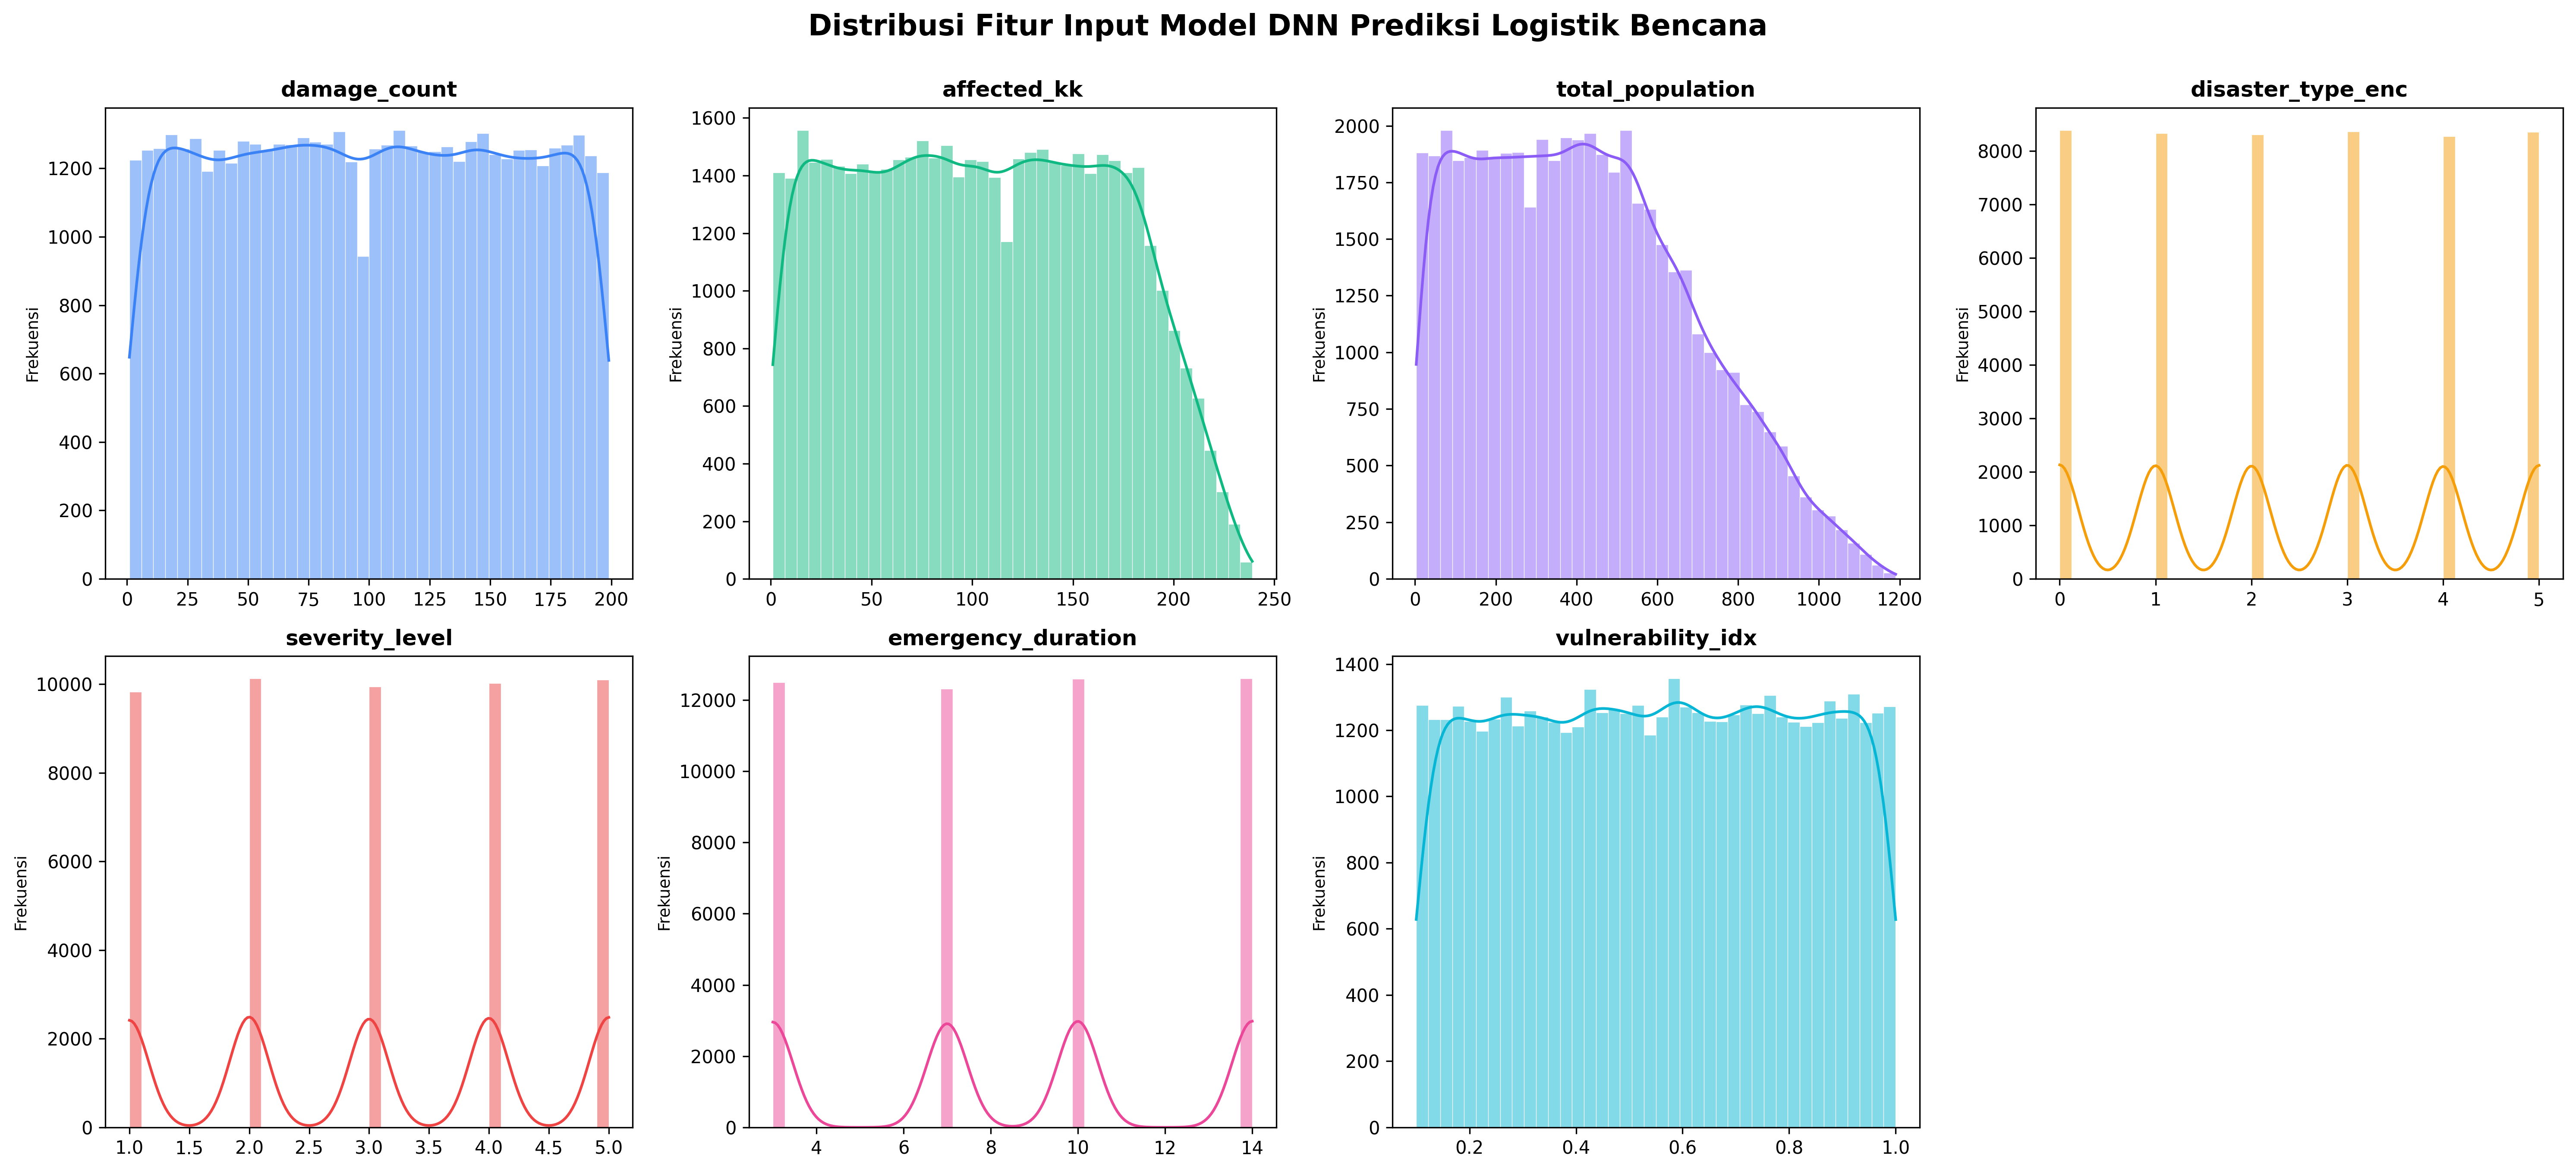

In [28]:
fig, axes = plt.subplots(2, 4, figsize=(20, 9), dpi=300)
axes = axes.flatten()
feature_colors = ['#3B82F6', '#10B981', '#8B5CF6', '#F59E0B', '#EF4444', '#EC4899', '#06B6D4']
for i, col in enumerate(x.columns):
    sns.histplot(x[col], kde=True, ax=axes[i], color=feature_colors[i], bins=40, edgecolor='white', linewidth=0.3)
    axes[i].set_title(col, fontsize=12, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Frekuensi', fontsize=9)
axes[7].axis('off')
plt.suptitle('Distribusi Fitur Input Model DNN Prediksi Logistik Bencana', fontsize=16, fontweight='bold', y=1.00)
plt.tight_layout()
plt.savefig('Feature_Distribution_Analysis.png', dpi=300, bbox_inches='tight')
plt.show()

In [29]:
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [30]:
mean_vals = X_train.mean().values
std_vals = X_train.std().values

In [31]:
norm_layer = Normalization(mean=mean_vals, variance=std_vals**2)

In [32]:
from shapely.geometry import shape

In [33]:
model = Sequential()

model.add(Input(shape=(7,)))

model.add(norm_layer)

model.add(Dense(256, activation="relu"))
model.add(BatchNormalization())
model.add(Dropout(0.3))

model.add(Dense(128, activation="relu"))
model.add(BatchNormalization())
model.add(Dropout(0.3))

model.add(Dense(64, activation="relu"))
model.add(BatchNormalization())

model.add(Dense(32, activation="relu"))

model.add(Dense(y_train.shape[1], activation="linear"))

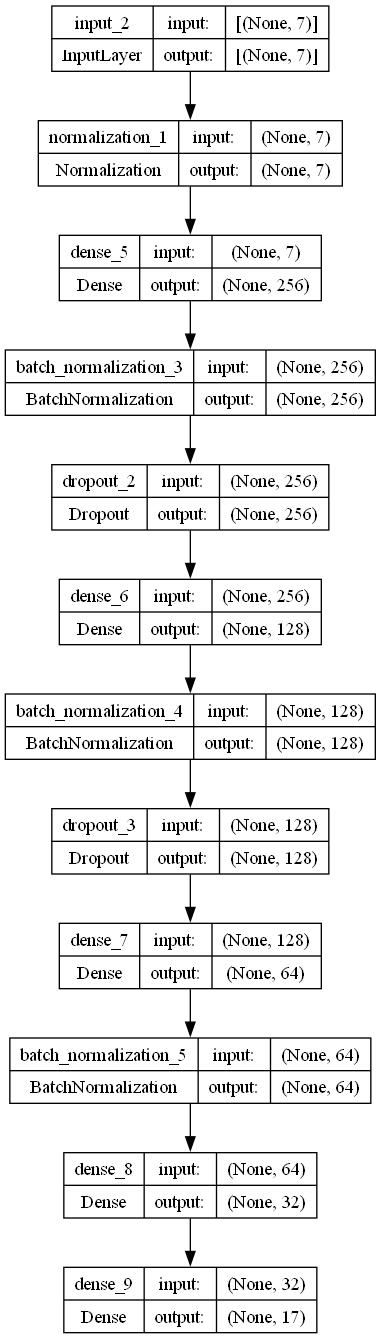

In [34]:
plot_model(
    model,
    to_file='arsitektur_model_logistics.png',
    show_shapes=True,
    show_layer_names=True,
    rankdir='TB',
    expand_nested=True,
    dpi=96
)

In [35]:
model.compile(optimizer=Adam(learning_rate=0.002), loss='mse', metrics=['mae'])

In [36]:
model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 normalization_1 (Normalizat  (None, 7)                0         
 ion)                                                            
                                                                 
 dense_5 (Dense)             (None, 256)               2048      
                                                                 
 batch_normalization_3 (Batc  (None, 256)              1024      
 hNormalization)                                                 
                                                                 
 dropout_2 (Dropout)         (None, 256)               0         
                                                                 
 dense_6 (Dense)             (None, 128)               32896     
                                                                 
 batch_normalization_4 (Batc  (None, 128)             

In [37]:
history = model.fit(
    X_train.values, y_train.values,
    validation_split=0.2,
    epochs=30,
    batch_size=128,
    verbose=1
)

Epoch 1/30
250/250 [==============================] - 2s 5ms/step - loss: 23180.5352 - mae: 73.3986 - val_loss: 3032.4832 - val_mae: 31.2621
Epoch 2/30
250/250 [==============================] - 1s 4ms/step - loss: 1142.1144 - mae: 20.7000 - val_loss: 516.1782 - val_mae: 15.6523
Epoch 3/30
250/250 [==============================] - 1s 3ms/step - loss: 846.5759 - mae: 17.8220 - val_loss: 248.8827 - val_mae: 9.7341
Epoch 4/30
250/250 [==============================] - 1s 3ms/step - loss: 750.5289 - mae: 16.6591 - val_loss: 245.6401 - val_mae: 9.2677
Epoch 5/30
250/250 [==============================] - 1s 3ms/step - loss: 596.9710 - mae: 14.6228 - val_loss: 306.7788 - val_mae: 11.3873
Epoch 6/30
250/250 [==============================] - 1s 3ms/step - loss: 547.9028 - mae: 13.4963 - val_loss: 124.3267 - val_mae: 6.2597
Epoch 7/30
250/250 [==============================] - 1s 3ms/step - loss: 463.1959 - mae: 12.2041 - val_loss: 143.4419 - val_mae: 7.3543
Epoch 8/30
250/250 [==============

In [38]:
Y_pred_dl = model.predict(X_test.values)
r2_dl = r2_score(y_test, Y_pred_dl)
mae_dl = mean_absolute_error(y_test, Y_pred_dl)
rmse_dl = np.sqrt(mean_squared_error(y_test, Y_pred_dl))

313/313 [==============================] - 1s 2ms/step


In [39]:
print(f"R2 Score: {r2_dl:.4f} ({r2_dl*100:.2f}%)")
print(f"MAE: {mae_dl:.4f}")
print(f"RMSE: {rmse_dl:.4f}")

R2 Score: 0.9816 (98.16%)
MAE: 4.0924
RMSE: 8.1812


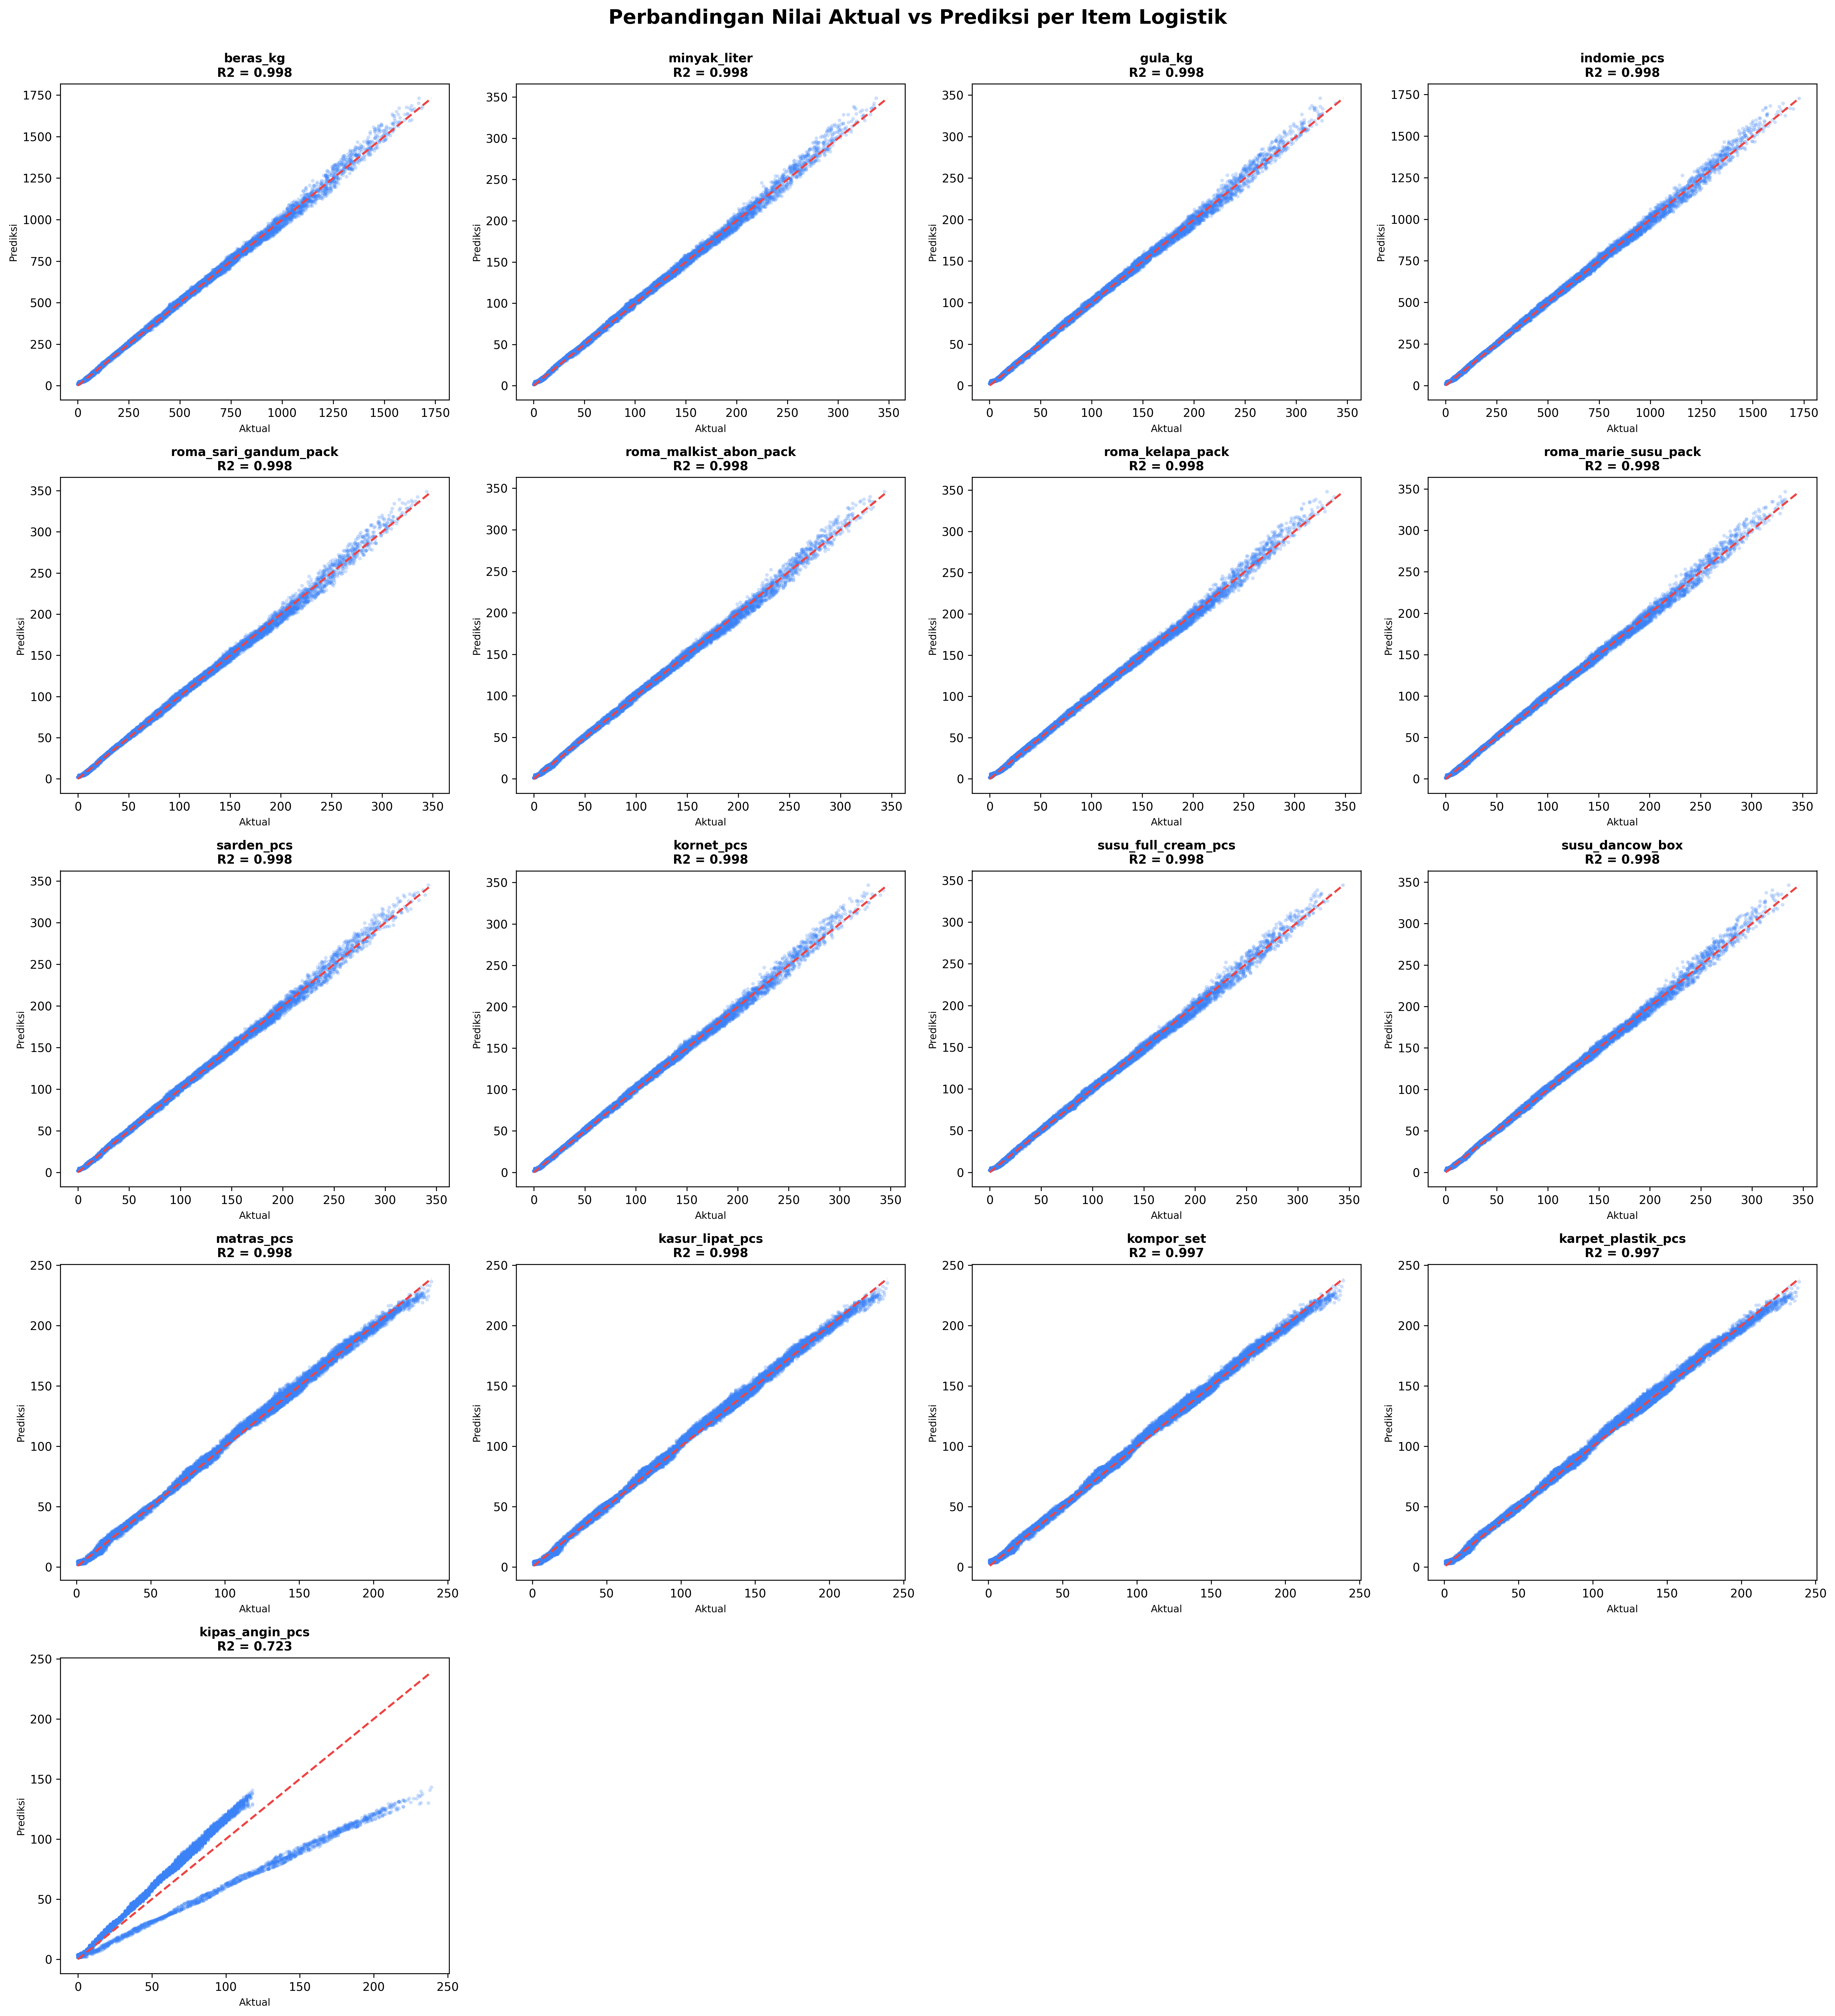

In [41]:
fig, axes = plt.subplots(5, 4, figsize=(22, 24), dpi=300)
axes = axes.flatten()
for i, col in enumerate(y.columns):
    actual = y_test[col].values
    predicted = Y_pred_dl[:, i]
    axes[i].scatter(actual, predicted, alpha=0.25, s=10, color="#3B82F6", edgecolors="none")
    min_val = min(actual.min(), predicted.min())
    max_val = max(actual.max(), predicted.max())
    axes[i].plot([min_val, max_val], [min_val, max_val], color="#EF4444", linewidth=1.8, linestyle="--")
    r2_item = r2_score(actual, predicted)
    axes[i].set_title(f"{col}\nR2 = {r2_item:.3f}", fontsize=10.5, fontweight="bold")
    axes[i].set_xlabel("Aktual", fontsize=8.5)
    axes[i].set_ylabel("Prediksi", fontsize=8.5)
for j in range(len(y.columns), len(axes)):
    axes[j].axis("off")
plt.suptitle("Perbandingan Nilai Aktual vs Prediksi per Item Logistik", fontsize=17, fontweight="bold", y=1.00)
plt.tight_layout()
plt.savefig("Prediction_vs_Actual_Comparison.png", dpi=300, bbox_inches="tight")
plt.show()

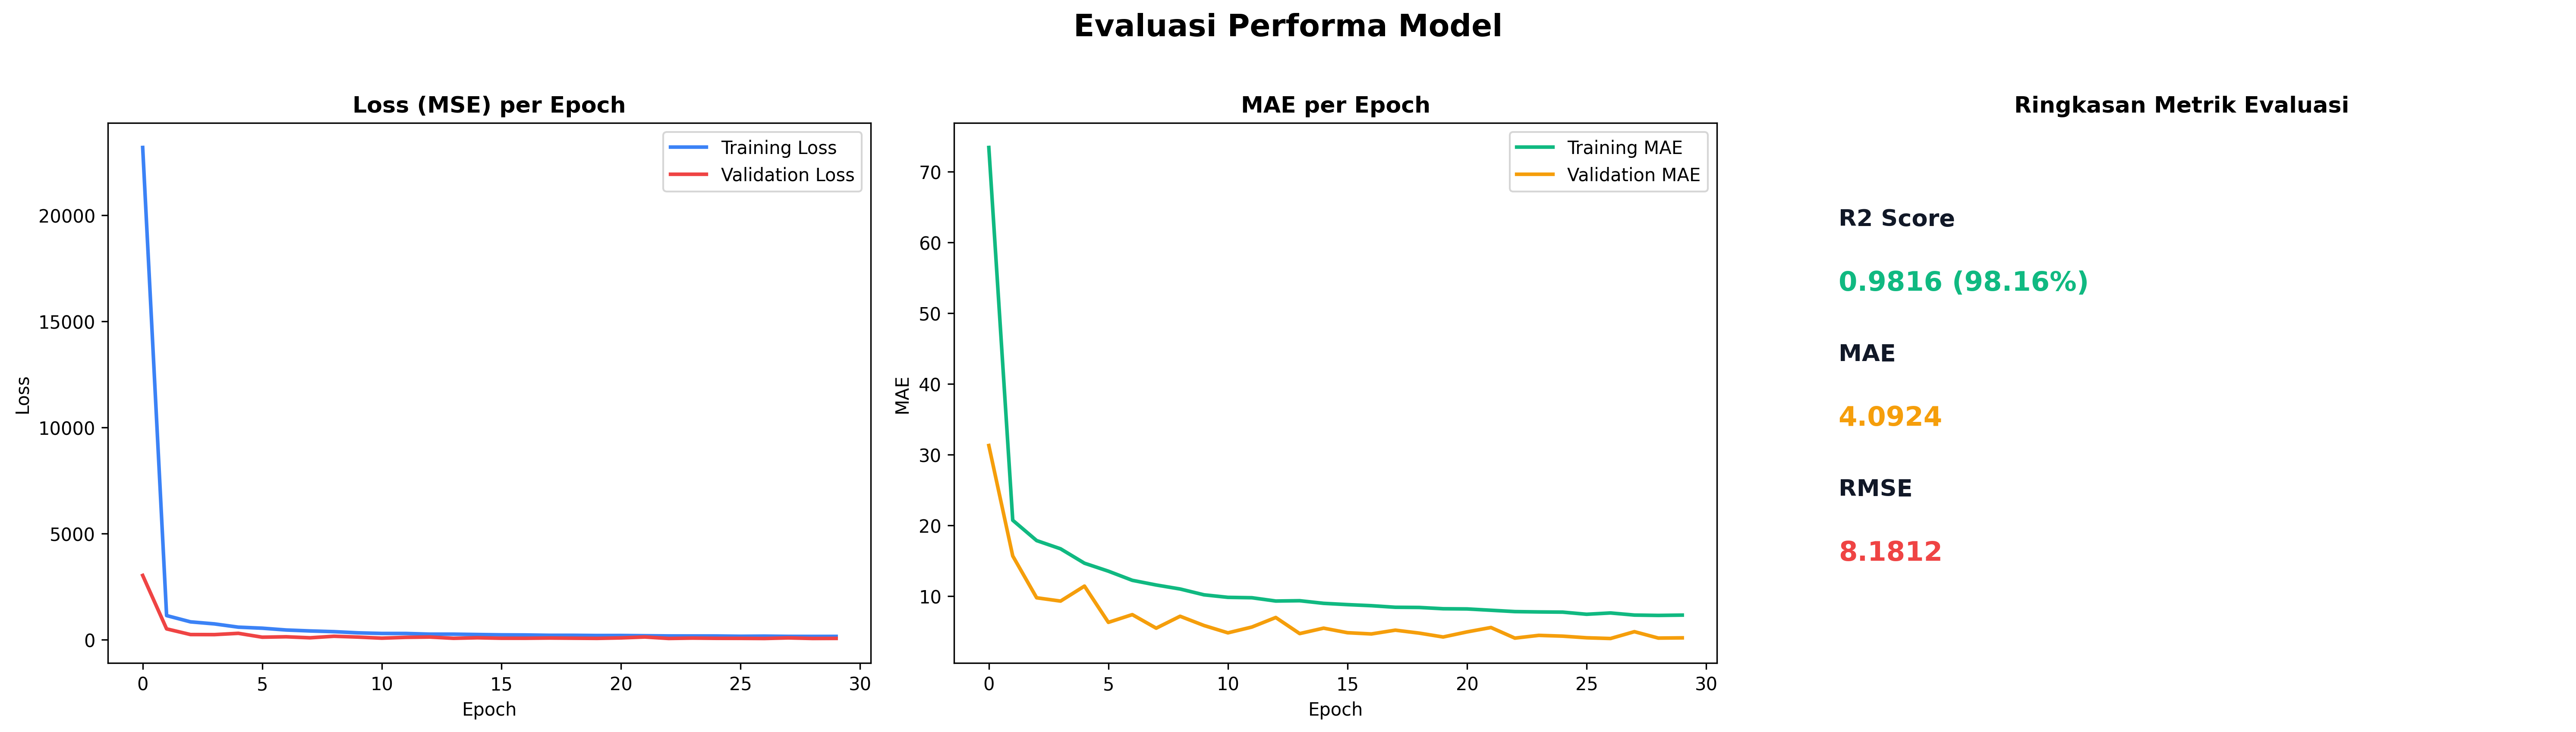

In [42]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5.5), dpi=300)
axes[0].plot(history.history["loss"], color="#3B82F6", linewidth=2, label="Training Loss")
axes[0].plot(history.history["val_loss"], color="#EF4444", linewidth=2, label="Validation Loss")
axes[0].set_title("Loss (MSE) per Epoch", fontsize=12.5, fontweight="bold")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[1].plot(history.history["mae"], color="#10B981", linewidth=2, label="Training MAE")
axes[1].plot(history.history["val_mae"], color="#F59E0B", linewidth=2, label="Validation MAE")
axes[1].set_title("MAE per Epoch", fontsize=12.5, fontweight="bold")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("MAE")
axes[1].legend()
axes[2].axis("off")
metric_labels = ["R2 Score", "MAE", "RMSE"]
metric_values = [r2_dl, mae_dl, rmse_dl]
metric_colors = ["#10B981", "#F59E0B", "#EF4444"]
y_pos = [0.75, 0.5, 0.25]
axes[2].set_xlim(0, 1)
axes[2].set_ylim(0, 1)
for label, val, color, yp in zip(metric_labels, metric_values, metric_colors, y_pos):
    axes[2].text(0.05, yp + 0.06, label, fontsize=13, fontweight="bold", color="#111827")
    display_val = f"{val:.4f} ({val*100:.2f}%)" if label == "R2 Score" else f"{val:.4f}"
    axes[2].text(0.05, yp - 0.06, display_val, fontsize=15, fontweight="bold", color=color)
axes[2].set_title("Ringkasan Metrik Evaluasi", fontsize=12.5, fontweight="bold")
plt.suptitle("Evaluasi Performa Model", fontsize=17, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("Evaluation_Metrics_Summary.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
model.save("model_logistics.h5")